In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [37]:
from sklearn.preprocessing import MinMaxScaler

In [38]:
# Load Sylhet Division dataset
df = pd.read_csv("../smart_grid_dataset_sylhet.csv")

In [39]:
# Step 1: Dataset inspection - head()
# Verify the data loaded correctly and check the first few rows
df.head()

,datetime,division,district,upazila,temperature,humidity,rainfall,demand_index,risk_level
0,2026-04-13 00:00:00,Sylhet,Habiganj,Ajmiriganj,23.0,83,0.0,0.4110,Low
1,2026-04-13 02:00:00,Sylhet,Habiganj,Ajmiriganj,23.5,93,0.0,0.4385,Low
2,2026-04-13 04:00:00,Sylhet,Habiganj,Ajmiriganj,22.9,90,0.1,0.4232,Low
3,2026-04-13 06:00:00,Sylhet,Habiganj,Ajmiriganj,24.4,98,0.0,0.7620,High
4,2026-04-13 08:00:00,Sylhet,Habiganj,Ajmiriganj,20.9,96,0.3,0.7047,High


In [40]:
# Step 2: Dataset inspection - info()
# Check column dtypes, non-null counts and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14880 entries, 0 to 14879
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datetime      14880 non-null  object 
 1   division      14880 non-null  object 
 2   district      14880 non-null  object 
 3   upazila       14880 non-null  object 
 4   temperature   14880 non-null  float64
 5   humidity      14880 non-null  int64  
 6   rainfall      14880 non-null  float64
 7   demand_index  14880 non-null  float64
 8   risk_level    14880 non-null  object 
dtypes: float64(3), int64(1), object(5)
memory usage: 1.0+ MB


In [41]:
# Step 3: Dataset inspection - describe()
# Statistical summary of all numerical features
df.describe()

,temperature,humidity,rainfall,demand_index
count,14880.000000,14880.000000,14880.000000,14880.000000
mean,25.301915,84.341331,0.636237,0.766503
std,3.265123,12.457354,1.947223,0.227484
min,19.800000,46.000000,0.000000,0.371200
25%,22.600000,75.000000,0.000000,0.566750
50%,24.700000,88.000000,0.000000,0.821850
75%,27.800000,95.000000,0.200000,1.000000
max,33.500000,100.000000,23.400000,1.000000


In [42]:
# Step 4: Null value check
# Confirm there are no missing values before preprocessing
df.isnull().sum()

datetime        0
division        0
district        0
upazila         0
temperature     0
humidity        0
rainfall        0
demand_index    0
risk_level      0
dtype: int64

In [43]:
# Step 5: Confirm Sylhet division only
print("Division:", df['division'].unique())
print("Districts:", df['district'].unique())
print("Total Upazilas:", df['upazila'].nunique())
print("Total Rows:", len(df))

Division: ['Sylhet']
Districts: ['Habiganj' 'Maulvibazar' 'Sunamganj' 'Sylhet']
Total Upazilas: 40
Total Rows: 14880


In [44]:
# Step 6: Parse datetime and sort chronologically
# Time-series data must be sorted by upazila then time - NO random shuffling
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values(['upazila', 'datetime']).reset_index(drop=True)

print("Date range:", df['datetime'].min(), "-->", df['datetime'].max())

Date range: 2026-04-13 00:00:00 --> 2026-05-13 22:00:00


In [45]:
# Step 7: Encode target labels (ordinal encoding - risk has natural order)
# Low=0, Medium=1, High=2
risk_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['risk_encoded'] = df['risk_level'].map(risk_map)

print("Label distribution:")
df['risk_encoded'].value_counts().sort_index()

Label distribution:


risk_encoded
0    2998
1    2177
2    9705
Name: count, dtype: int64

In [46]:
# Step 8: Feature engineering - extract temporal features from datetime
# These help the model learn time-of-day and day-of-week demand patterns
df['hour']    = df['datetime'].dt.hour       # 0-23
df['day']     = df['datetime'].dt.day        # 1-31
df['month']   = df['datetime'].dt.month      # 4-5 in this dataset
df['weekday'] = df['datetime'].dt.weekday    # 0=Monday, 6=Sunday

# Peak-hour flag: morning (6-10) and evening (18-22) are high-demand windows in Sylhet
df['peak_hour'] = df['hour'].apply(lambda h: 1 if (6 <= h <= 10) or (18 <= h <= 22) else 0)

df[['datetime', 'hour', 'day', 'month', 'weekday', 'peak_hour']].head()

,datetime,hour,day,month,weekday,peak_hour
0,2026-04-13 00:00:00,0,13,4,0,0
1,2026-04-13 02:00:00,2,13,4,0,0
2,2026-04-13 04:00:00,4,13,4,0,0
3,2026-04-13 06:00:00,6,13,4,0,1
4,2026-04-13 08:00:00,8,13,4,0,1


In [47]:
# Step 9: Feature selection
# Select numerical features relevant for load shedding risk forecasting
feature_cols = [
    'temperature',   # real weather - primary demand driver
    'humidity',      # real weather - secondary demand driver
    'rainfall',      # real weather - demand suppressor
    'demand_index',  # simulated electricity demand
    'hour',          # time-of-day pattern
    'day',           # day-of-month
    'month',         # seasonal pattern
    'weekday',       # weekday vs weekend demand
    'peak_hour',     # binary peak-hour indicator
]
target_col = 'risk_encoded'

print(f"Features ({len(feature_cols)}):", feature_cols)

Features (9): ['temperature', 'humidity', 'rainfall', 'demand_index', 'hour', 'day', 'month', 'weekday', 'peak_hour']


In [48]:
# Step 10: Separate features (X) and target (y)
X_raw = df[feature_cols].values
y_raw = df[target_col].values

print("X shape:", X_raw.shape)
print("y shape:", y_raw.shape)

X shape: (14880, 9)
y shape: (14880,)


In [49]:
# Step 11: Normalize features using MinMaxScaler [0, 1]
# Essential for LSTM convergence - prevents any single feature dominating gradients
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X_raw)

print("Scaling complete. Range: [0, 1]")
print("Min per feature:", X_scaled.min(axis=0).round(4))
print("Max per feature:", X_scaled.max(axis=0).round(4))

Scaling complete. Range: [0, 1]
Min per feature: [0. 0. 0. 0. 0. 0. 0. 0. 0.]
Max per feature: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [50]:
# Step 12: Upazila-wise sequence generation (PRODUCTION-LEVEL)
#
# WHY UPAZILA-WISE SEQUENCE GENERATION IS CRITICAL:
# In a multi-entity time-series dataset, global sequence generation slides a
# window across ALL rows regardless of entity boundaries. This causes the last
# timestep of Upazila A and the first timestep of Upazila B to be merged into
# a single sequence — a temporal contamination that introduces nonsensical
# cross-Upazila transitions. The LSTM then learns spurious patterns that do not
# exist in reality, degrading forecast quality. Upazila-wise generation ensures
# each sequence contains only temporally contiguous observations from a single
# Upazila, preserving true causal structure.
#
# APPROACH:
#   - Group the scaled feature matrix and target vector by Upazila
#   - Generate sequences independently within each Upazila's time-series
#   - Concatenate all Upazila sequences into the final dataset
#   - Preserve chronological order; NO random shuffling

SEQ_LEN = 6  # 6 steps x 2 hours = 12-hour look-back window

def create_sequences_for_upazila(X, y, seq_len):
    """Generate sliding-window sequences for a single Upazila time-series."""
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_len):
        X_seq.append(X[i : i + seq_len])
        y_seq.append(y[i + seq_len])
    return X_seq, y_seq

# Attach the scaled features back to the dataframe index for grouping
X_seq_all, y_seq_all = [], []

for upazila_name, group in df.groupby('upazila', sort=False):
    # Extract the row indices belonging to this Upazila
    idx = group.index
    X_up = X_scaled[idx]   # scaled features for this Upazila
    y_up = y_raw[idx]      # encoded labels for this Upazila

    # Generate sequences only within this Upazila's time-series
    X_s, y_s = create_sequences_for_upazila(X_up, y_up, SEQ_LEN)
    X_seq_all.extend(X_s)
    y_seq_all.extend(y_s)

X_seq = np.array(X_seq_all)
y_seq = np.array(y_seq_all)

print("[OK] Upazila-wise sequence generation complete.")
print("X_seq shape:", X_seq.shape, "  --> (samples, timesteps, features)")
print("y_seq shape:", y_seq.shape, "  --> (samples,)")

[OK] Upazila-wise sequence generation complete.
X_seq shape: (14640, 6, 9)   --> (samples, timesteps, features)
y_seq shape: (14640,)   --> (samples,)


In [51]:
# Step 13: Chronological train/test split (80/20)
# Split by index position - NO random shuffling - preserves temporal causality
split = int(len(X_seq) * 0.80)

X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

print("=" * 45)
print("  Final Dataset Shapes")
print("=" * 45)
print(f"  X_train (LSTM)  : {X_train.shape}")
print(f"  X_test  (LSTM)  : {X_test.shape}")
print(f"  y_train         : {y_train.shape}")
print(f"  y_test          : {y_test.shape}")
print(f"  Train split     : {len(X_train)/len(X_seq)*100:.1f}%")
print(f"  Test  split     : {len(X_test)/len(X_seq)*100:.1f}%")
print("=" * 45)

  Final Dataset Shapes
  X_train (LSTM)  : (11712, 6, 9)
  X_test  (LSTM)  : (2928, 6, 9)
  y_train         : (11712,)
  y_test          : (2928,)
  Train split     : 80.0%
  Test  split     : 20.0%


In [52]:
# Step 14: Flatten sequences for Random Forest / XGBoost (requires 2D input)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0],  -1)

print(f"  X_train (LSTM)       : {X_train.shape}")
print(f"  X_train_flat (RF/XGB): {X_train_flat.shape}")
print(f"  X_test  (LSTM)       : {X_test.shape}")
print(f"  X_test_flat  (RF/XGB): {X_test_flat.shape}")

  X_train (LSTM)       : (11712, 6, 9)
  X_train_flat (RF/XGB): (11712, 54)
  X_test  (LSTM)       : (2928, 6, 9)
  X_test_flat  (RF/XGB): (2928, 54)


In [53]:
# Step 15: Save fitted MinMaxScaler using joblib
# The scaler MUST be saved after fit_transform so it can be reused at
# inference time to scale new input data with the same min/max parameters.
import joblib
import os

SAVE_DIR = '../preprocessed'
os.makedirs(SAVE_DIR, exist_ok=True)

scaler_path = os.path.join(SAVE_DIR, 'feature_scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"[SAVED] Scaler --> {scaler_path}")

[SAVED] Scaler --> ../preprocessed\feature_scaler.pkl


In [54]:
# Step 16: Save preprocessed datasets as .npy files
#
# X_train / X_test  : 3-D arrays (samples, timesteps, features) for LSTM
# y_train / y_test  : 1-D arrays (samples,) of encoded risk labels
#
# These files are fully compatible with:
#   - LSTM  : use X_train / X_test directly (3-D)
#   - RF/XGB: reshape to 2-D via X_train.reshape(n, -1) at training time

np.save(os.path.join(SAVE_DIR, 'X_train.npy'), X_train)
np.save(os.path.join(SAVE_DIR, 'X_test.npy'),  X_test)
np.save(os.path.join(SAVE_DIR, 'y_train.npy'), y_train)
np.save(os.path.join(SAVE_DIR, 'y_test.npy'),  y_test)

print(f"[SAVED] X_train.npy --> shape {X_train.shape}")
print(f"[SAVED] X_test.npy  --> shape {X_test.shape}")
print(f"[SAVED] y_train.npy --> shape {y_train.shape}")
print(f"[SAVED] y_test.npy  --> shape {y_test.shape}")
print()
print('=== Preprocessing pipeline complete. All artifacts saved. ===')

[SAVED] X_train.npy --> shape (11712, 6, 9)
[SAVED] X_test.npy  --> shape (2928, 6, 9)
[SAVED] y_train.npy --> shape (11712,)
[SAVED] y_test.npy  --> shape (2928,)

=== Preprocessing pipeline complete. All artifacts saved. ===


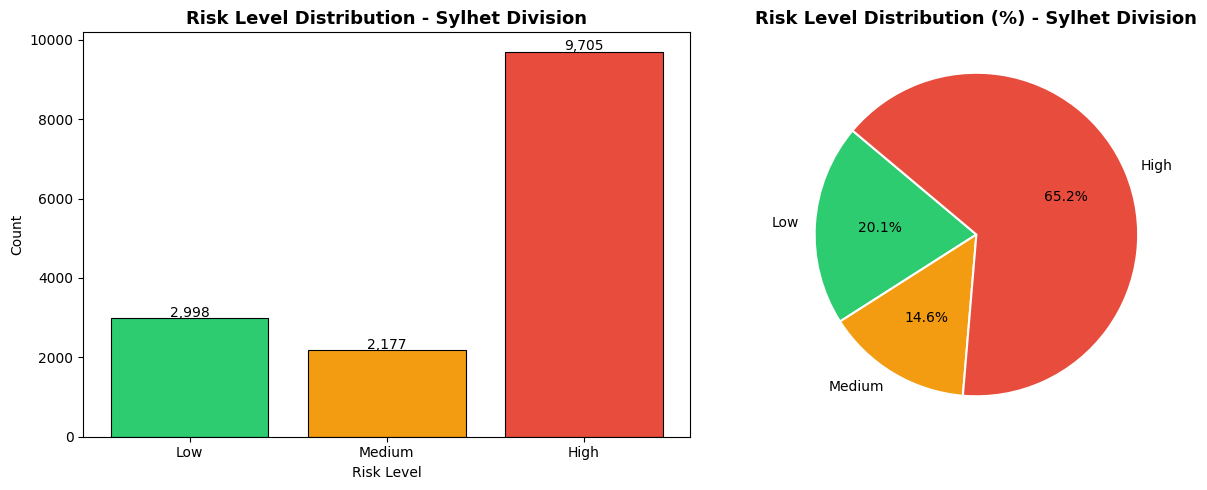

In [55]:
# Visualization 1: Risk level distribution (bar + pie)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = df['risk_level'].value_counts().reindex(['Low', 'Medium', 'High'])
colors = ['#2ecc71', '#f39c12', '#e74c3c']

axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Risk Level Distribution - Sylhet Division', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontsize=10)

axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Risk Level Distribution (%) - Sylhet Division', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

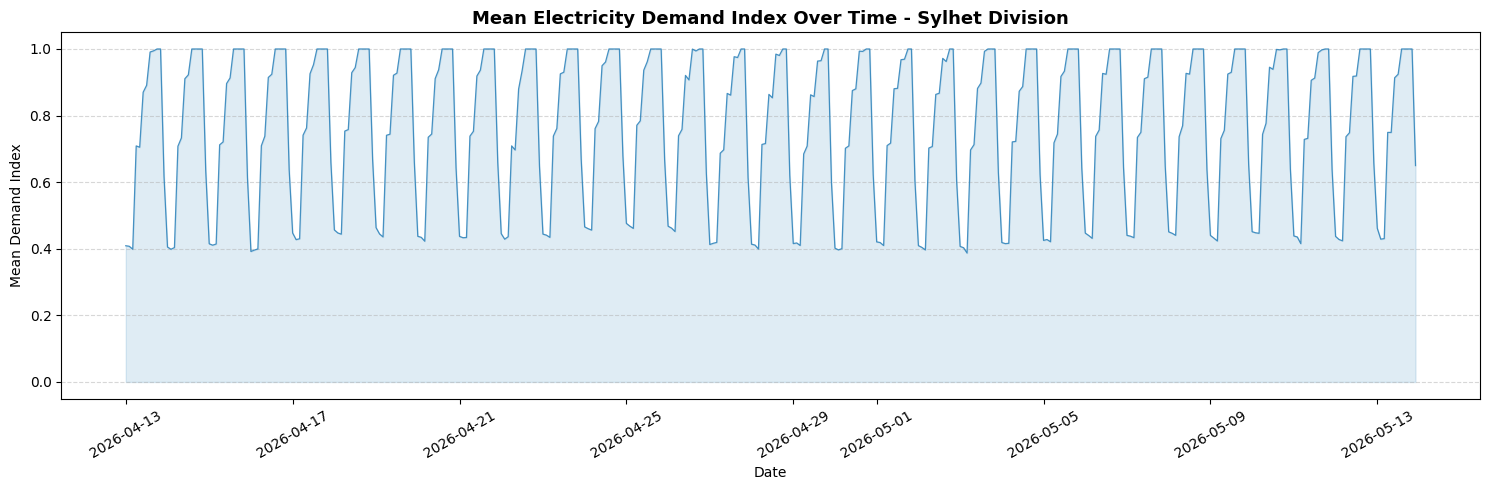

In [56]:
# Visualization 2: Demand trend over time (mean across all Sylhet upazilas)
demand_trend = df.groupby('datetime')['demand_index'].mean().reset_index()

plt.figure(figsize=(15, 5))
plt.plot(demand_trend['datetime'], demand_trend['demand_index'],
         color='#2980b9', linewidth=0.9, alpha=0.85)
plt.fill_between(demand_trend['datetime'], demand_trend['demand_index'],
                 alpha=0.15, color='#2980b9')
plt.title('Mean Electricity Demand Index Over Time - Sylhet Division', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Mean Demand Index')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

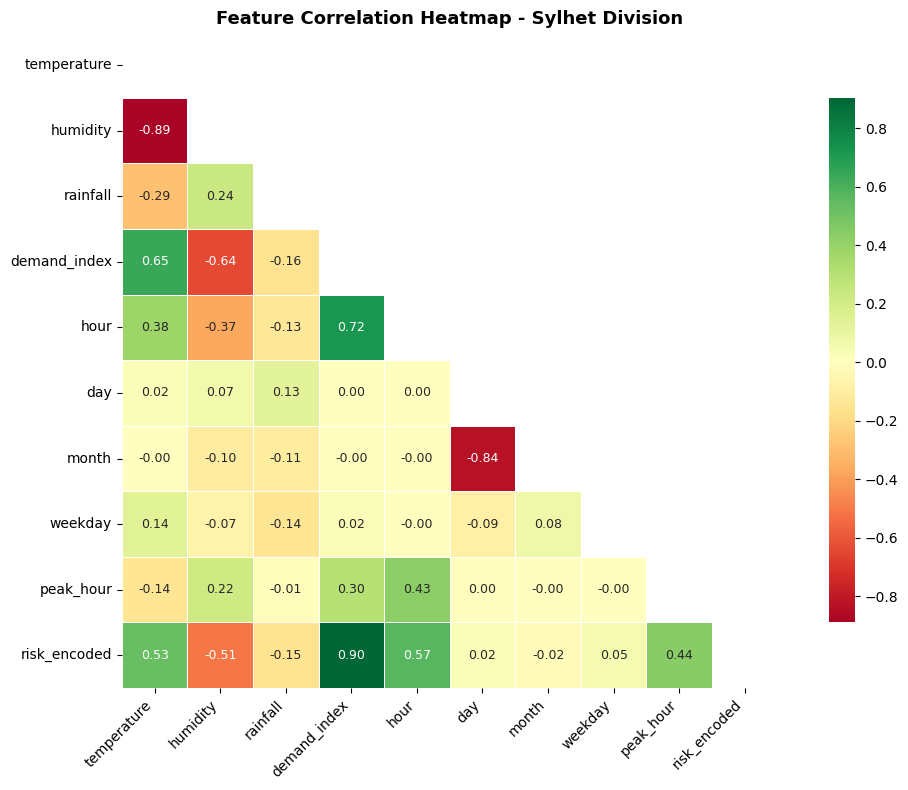

In [57]:
# Visualization 3: Feature correlation heatmap (lower triangle only)
corr_matrix = df[feature_cols + [target_col]].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 9}, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap - Sylhet Division', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

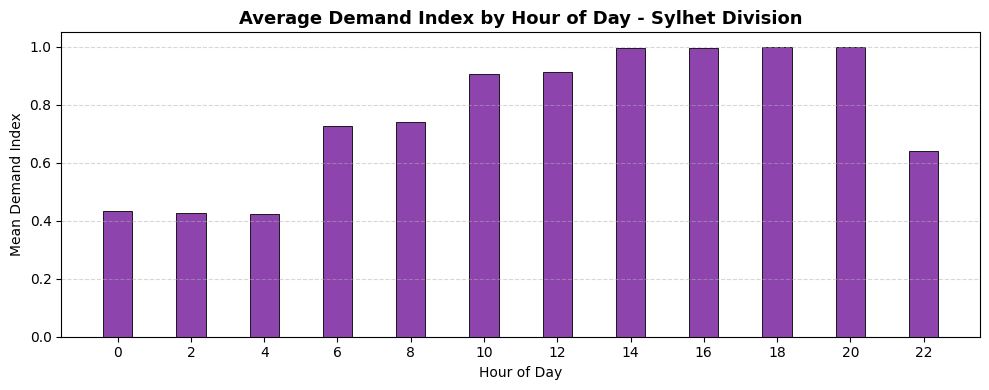

In [58]:
# Visualization 4: Average demand by hour of day
hourly = df.groupby('hour')['demand_index'].mean()

plt.figure(figsize=(10, 4))
plt.bar(hourly.index, hourly.values, color='#8e44ad', edgecolor='black', linewidth=0.6)
plt.title('Average Demand Index by Hour of Day - Sylhet Division', fontsize=13, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Mean Demand Index')
plt.xticks(range(0, 24, 2))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

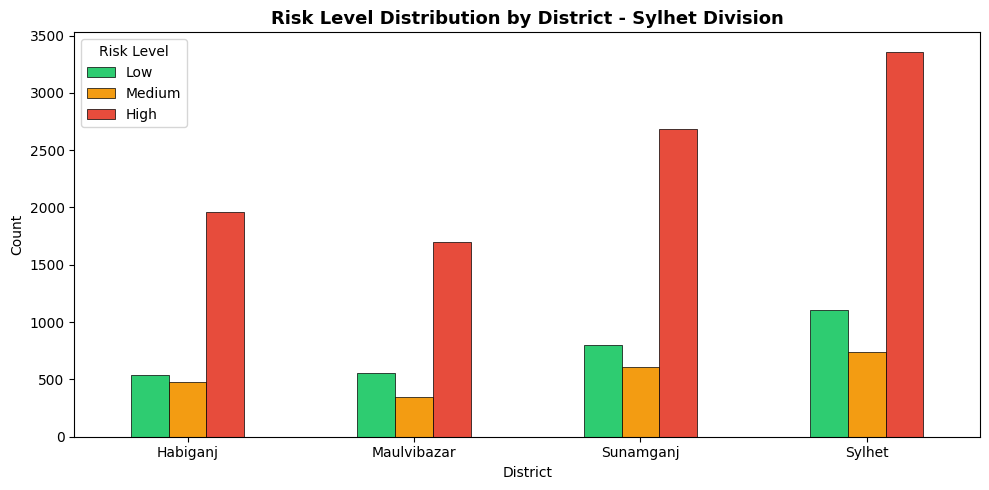

In [59]:
# Visualization 5: Risk level distribution per district
district_risk = df.groupby(['district', 'risk_level']).size().unstack(fill_value=0)
district_risk = district_risk[['Low', 'Medium', 'High']]

district_risk.plot(kind='bar', figsize=(10, 5), color=['#2ecc71', '#f39c12', '#e74c3c'],
                   edgecolor='black', linewidth=0.5)
plt.title('Risk Level Distribution by District - Sylhet Division', fontsize=13, fontweight='bold')
plt.xlabel('District')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Risk Level')
plt.tight_layout()
plt.show()

In [60]:
# Final preprocessing summary
print("=" * 50)
print("  SmartGrid Sentinel - Preprocessing Summary")
print("  Sylhet Division, Bangladesh")
print("=" * 50)
print(f"  Division              : Sylhet")
print(f"  Districts             : {df['district'].nunique()}")
print(f"  Upazilas              : {df['upazila'].nunique()}")
print(f"  Total samples (raw)   : {len(df):,}")
print(f"  Total sequences       : {len(X_seq):,}")
print(f"  Sequence length       : {SEQ_LEN} steps (12-hour window)")
print(f"  Features              : {len(feature_cols)}")
print("-" * 50)
print(f"  X_train  (LSTM)       : {X_train.shape}")
print(f"  X_test   (LSTM)       : {X_test.shape}")
print(f"  y_train               : {y_train.shape}")
print(f"  y_test                : {y_test.shape}")
print("-" * 50)
print(f"  X_train_flat (RF/XGB) : {X_train_flat.shape}")
print(f"  X_test_flat  (RF/XGB) : {X_test_flat.shape}")
print("=" * 50)
print("  Null values           : 0")
print("  Shuffling applied     : No")
print("  Scaler                : MinMaxScaler [0, 1]")
print("  Target encoding       : Low=0 | Med=1 | High=2")
print("=" * 50)

  SmartGrid Sentinel - Preprocessing Summary
  Sylhet Division, Bangladesh
  Division              : Sylhet
  Districts             : 4
  Upazilas              : 40
  Total samples (raw)   : 14,880
  Total sequences       : 14,640
  Sequence length       : 6 steps (12-hour window)
  Features              : 9
--------------------------------------------------
  X_train  (LSTM)       : (11712, 6, 9)
  X_test   (LSTM)       : (2928, 6, 9)
  y_train               : (11712,)
  y_test                : (2928,)
--------------------------------------------------
  X_train_flat (RF/XGB) : (11712, 54)
  X_test_flat  (RF/XGB) : (2928, 54)
  Null values           : 0
  Shuffling applied     : No
  Scaler                : MinMaxScaler [0, 1]
  Target encoding       : Low=0 | Med=1 | High=2
